# Aprendizado de Autômatos vs Aprendizado de Máquina

Este notebook implementa e compara duas estratégias de inferência de modelos comportamentais a partir de logs de execução:

- **Aprendizado de Autômatos** (AALpy): RPNI, GSM e L*
- **Aprendizado Estatístico** (Agilkia): EventCoverage e EventPairCoverage

A avaliação é feita por **cobertura de transições** e **teste de mutação** (Mutation Score).

**Dataset:** logs de um sistema de scanner de supermercado  
**Fonte:** https://github.com/PHILAE-PROJECT/agilkia/tree/master/examples/scanner

## 1. Instalação e dependências

In [1]:
!pip install aalpy agilkia -q

import pandas as pd
import numpy as np
import re
import random
import time
import matplotlib.pyplot as plt
from IPython.display import Image
import os

print('Dependências instaladas com sucesso.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.5/185.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.5 MB/s eta 0:00:00
Dependências instaladas com sucesso.


## 2. Carregamento e pré-processamento dos dados

In [2]:
from google.colab import files

print('Faça o upload do arquivo 127.0.0.1-1571403244552.csv')
uploaded = files.upload()

filename = '127.0.0.1-1571403244552.csv'
df = pd.read_csv(filename)
df.columns = ['id', 'timestamp', 'client', 'scan', 'action', 'params', 'status']
df = df.drop(columns=['timestamp'])

print(f'DataFrame carregado. Linhas: {len(df)}')
df.head()

Faça o upload do arquivo 127.0.0.1-1571403244552.csv


Saving 127.0.0.1-1571403244552.csv to 127.0.0.1-1571403244552.csv
DataFrame carregado. Linhas: 65273


,id,client,scan,action,params,status
0,2,client0,scan0,scanner,[3020120029030],0
1,3,client1,scan1,debloquer,[],0
2,4,client2,scan2,debloquer,[],0
3,5,client3,scan3,debloquer,[],0
4,6,client2,scan2,scanner,[7640164630021],-2


In [3]:
# --- Parâmetros ---
def parse_params_raw(x):
    if not isinstance(x, str): return None
    x = x.strip()
    if x in ('[]', '[ ]', ''): return None
    match = re.findall(r'\[([^\]]*)\]', x)
    if match:
        return match[0].strip().replace("'", '')
    return None

def simplify_params_semantic(action, param_raw):
    if param_raw is None: return ''
    param_raw_lower = param_raw.lower()
    if 'caisse' in param_raw_lower: return '(caixa)'
    try:
        val = float(param_raw)
        return '(produto)' if val > 100000 else '(valor/qtd)'
    except ValueError:
        return f'({param_raw})' if len(param_raw) < 15 else '(param_longo)'

# --- Status ---
def simplificar_status(s):
    s = str(s).strip()
    if s == '0':   return 'ok'
    elif s == '-2': return 'erro'
    elif s == '?':  return 'void'
    else:
        try:
            float(s)
            return 'valor'
        except:
            return 'outro'

# --- Processamento ---
df['param_raw']  = df['params'].apply(parse_params_raw)
df['event']      = df.apply(lambda row: f"{row['action']}{simplify_params_semantic(row['action'], row['param_raw'])}", axis=1)
df['status_sem'] = df['status'].apply(simplificar_status)

# --- Geração dos traces ---
traces = df.groupby('client')['event'].apply(list).tolist()

traces_com_status = (
    df.groupby('client')
      .apply(lambda g: list(zip(g['event'], g['status_sem'])), include_groups=False)
      .tolist()
)

alphabet_real = list(df['event'].unique())

print(f'Alfabeto: {len(alphabet_real)} eventos únicos')
print(f'Alfabeto: {alphabet_real}')
print(f'Traces gerados: {len(traces)}')
print(f'\nDistribuição dos status:')
print(df['status_sem'].value_counts())

Alfabeto: 9 eventos únicos
Alfabeto: [' scanner(produto)', ' debloquer', ' transmission(caixa)', ' abandon', ' ouvrirSession', ' ajouter(produto)', ' fermerSession', ' payer(valor/qtd)', ' supprimer(produto)']
Traces gerados: 4818

Distribuição dos status:
status_sem
ok       54582
void      4814
erro      3026
valor     2851
Name: count, dtype: int64


## 3. Aprendizado passivo

Algoritmos passivos recebem apenas traces positivos (sem contraexemplos) e inferem um autômato que os aceite.

Executando RPNI...
PTA Construction Time: 0.02

RPNI Learning Time: 0.01
RPNI Learned 1 state automaton.
RPNI: autômato com 1 estado(s).
Visualization started in the background thread.
Model saved to dfa_rpni.png.


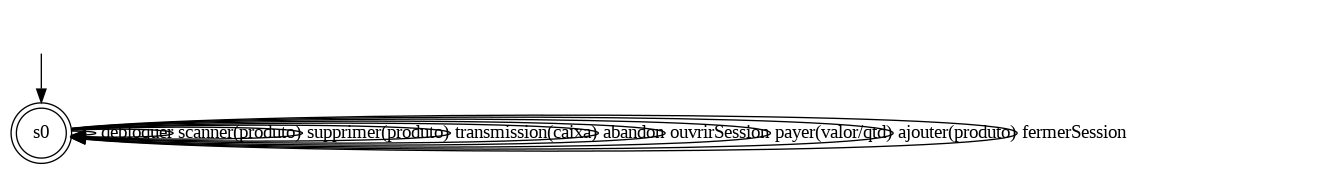

In [4]:
# --- RPNI ---
from aalpy.learning_algs.deterministic_passive.ClassicRPNI import ClassicRPNI
from aalpy.utils import visualize_automaton

positives = [(t, True) for t in traces]

print('Executando RPNI...')
rpni_helper = ClassicRPNI(positives, 'dfa', print_info=True)
dfa_rpni = rpni_helper.run_rpni()
print(f'RPNI: autômato com {len(dfa_rpni.states)} estado(s).')

visualize_automaton(dfa_rpni, path='dfa_rpni', file_type='png')
time.sleep(2)
if os.path.exists('dfa_rpni.png'):
    display(Image('dfa_rpni.png'))
else:
    print('Imagem ainda não disponível. Execute a célula de exibição novamente.')

Executando GSM...
GSM: autômato com 1 estado(s).
Visualization started in the background thread.
Model saved to dfa_gsm.png.


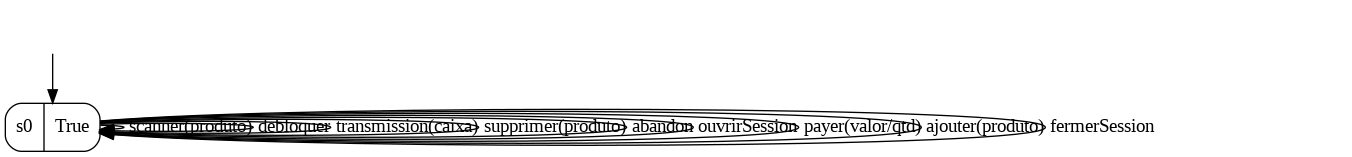

In [5]:
# --- GSM ---
from aalpy.learning_algs import run_GSM

gsm_data = [(list(map(str, t)), True) for t in traces]

print('Executando GSM...')
dfa_gsm = run_GSM(gsm_data, output_behavior='moore', transition_behavior='deterministic')
print(f'GSM: autômato com {len(dfa_gsm.states)} estado(s).')

visualize_automaton(dfa_gsm, path='dfa_gsm', file_type='png')
time.sleep(2)
display(Image('dfa_gsm.png'))

## 4. Aprendizado ativo — L* com SUL baseado em trie

O SUL (System Under Learning) é construído como uma **Trie** dos traces reais.
Dado qualquer sequência de eventos, retorna a saída observada nos logs.
Se o caminho nunca foi observado, retorna `nao_observado`.

In [6]:
from aalpy.SULs import SUL

class LogSUL(SUL):
    """
    SUL construído a partir dos traces reais do CSV via estrutura Trie.
    Dado qualquer sequência de eventos, consulta o caminho na Trie
    e retorna a saída observada nos logs reais.
    """
    def __init__(self, traces_com_status):
        super().__init__()
        self.trie = self._construir_trie(traces_com_status)
        self.no_atual = self.trie

    def _construir_trie(self, traces_com_status):
        trie = {}
        for trace in traces_com_status:
            no_atual = trie
            for evento, status in trace:
                evento = evento.strip()
                if evento not in no_atual:
                    no_atual[evento] = {'__saida__': status, '__filhos__': {}}
                no_atual = no_atual[evento]['__filhos__']
        return trie

    def pre(self):
        self.no_atual = self.trie

    def post(self):
        pass

    def step(self, letter):
        letter = letter.strip()
        if letter in self.no_atual:
            saida = self.no_atual[letter]['__saida__']
            self.no_atual = self.no_atual[letter]['__filhos__']
        else:
            saida = 'nao_observado'
            self.no_atual = {}
        return saida

print('LogSUL (Trie) definido.')

LogSUL (Trie) definido.


Hypothesis 1: 4 states.
-----------------------------------
Learning Finished.
Learning Rounds:  1
Number of states: 4
Time (in seconds)
  Total                : 0.31
  Learning algorithm   : 0.0
  Conformance checking : 0.31
Learning Algorithm
 # Membership Queries  : 324
 # MQ Saved by Caching : 9
 # Steps               : 891
Equivalence Query
 # Membership Queries  : 2000
 # Steps               : 36795
-----------------------------------

Modelo aprendido com 4 estados.
Visualization started in the background thread.
Model saved to model_trie.png.


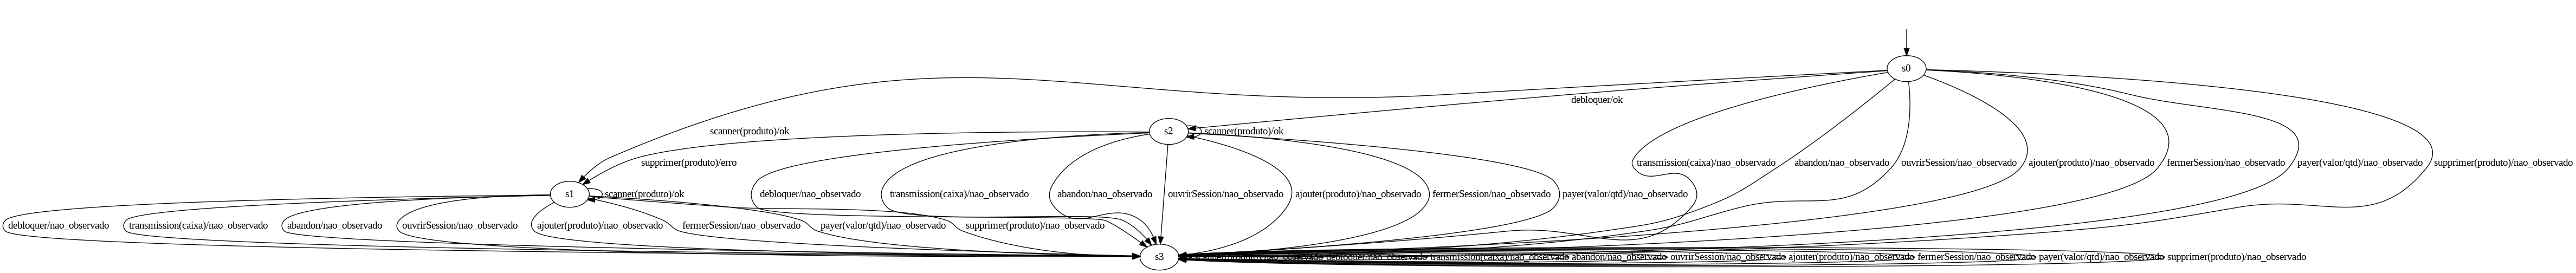

In [8]:
from aalpy.learning_algs import run_Lstar
from aalpy.oracles import RandomWpMethodEqOracle

sul_trie   = LogSUL(traces_com_status)
oracle_trie = RandomWpMethodEqOracle(
    alphabet_real, sul_trie,
    min_length=2, expected_length=15, num_tests=2000
)

model_trie = run_Lstar(
    alphabet_real, sul_trie, oracle_trie,
    automaton_type='mealy'
)

print(f'\nModelo aprendido com {len(model_trie.states)} estados.')

visualize_automaton(model_trie, path='model_trie', file_type='png')
time.sleep(2)
display(Image('model_trie.png'))

In [9]:
# --- Transições do modelo ---
print('Transições do modelo aprendido:')
for state in model_trie.states:
    for symbol in alphabet_real:
        destino = state.transitions[symbol].state_id
        saida   = state.output_fun[symbol]
        print(f'  {state.state_id} --[{symbol.strip()}]--> {destino}  (saída: {saida})')

Transições do modelo aprendido:
  s0 --[scanner(produto)]--> s1  (saída: ok)
  s0 --[debloquer]--> s2  (saída: ok)
  s0 --[transmission(caixa)]--> s3  (saída: nao_observado)
  s0 --[abandon]--> s3  (saída: nao_observado)
  s0 --[ouvrirSession]--> s3  (saída: nao_observado)
  s0 --[ajouter(produto)]--> s3  (saída: nao_observado)
  s0 --[fermerSession]--> s3  (saída: nao_observado)
  s0 --[payer(valor/qtd)]--> s3  (saída: nao_observado)
  s0 --[supprimer(produto)]--> s3  (saída: nao_observado)
  s1 --[scanner(produto)]--> s1  (saída: ok)
  s1 --[debloquer]--> s3  (saída: nao_observado)
  s1 --[transmission(caixa)]--> s3  (saída: nao_observado)
  s1 --[abandon]--> s3  (saída: nao_observado)
  s1 --[ouvrirSession]--> s3  (saída: nao_observado)
  s1 --[ajouter(produto)]--> s3  (saída: nao_observado)
  s1 --[fermerSession]--> s3  (saída: nao_observado)
  s1 --[payer(valor/qtd)]--> s3  (saída: nao_observado)
  s1 --[supprimer(produto)]--> s3  (saída: nao_observado)
  s2 --[scanner(produto)]--

## 5. Cobertura de transições do Modelo (AALpy)

Métrica de cobertura formal: percentual de transições da MEF exercitadas pelos traces reais.

```
Cobertura = transições visitadas / total de transições do modelo
```

In [10]:
state_map_trie = {s.state_id: s for s in model_trie.states}

todas_transicoes = set()
for state in model_trie.states:
    for symbol in alphabet_real:
        todas_transicoes.add((state.state_id, symbol))

transicoes_cobertas = set()
for trace in traces_com_status:
    estado_atual = model_trie.initial_state
    for evento, status in trace:
        evento_strip = evento.strip()
        simbolo = next((a for a in alphabet_real if a.strip() == evento_strip), None)
        if simbolo is None: break
        transicoes_cobertas.add((estado_atual.state_id, simbolo))
        estado_atual = estado_atual.transitions[simbolo]

transicoes_nao_cobertas = todas_transicoes - transicoes_cobertas
cobertura_pct = len(transicoes_cobertas) / len(todas_transicoes) * 100

print('=' * 50)
print(' COBERTURA DE TRANSIÇÕES — AALpy (L*)')
print('=' * 50)
print(f'Estados no modelo    : {len(model_trie.states)}')
print(f'Transições totais    : {len(todas_transicoes)}')
print(f'Transições cobertas  : {len(transicoes_cobertas)}')
print(f'Cobertura            : {cobertura_pct:.1f}%')
print()
print('Transições COBERTAS:')
for (estado, simbolo) in sorted(transicoes_cobertas):
    s = state_map_trie[estado]
    destino = s.transitions[simbolo].state_id
    saida   = s.output_fun[simbolo]
    print(f'  ✔ {estado} --[{simbolo.strip()}]--> {destino}  (saída: {saida})')
print()
print('Transições NÃO COBERTAS (sequências nunca observadas nos logs):')
for (estado, simbolo) in sorted(transicoes_nao_cobertas):
    s = state_map_trie[estado]
    destino = s.transitions[simbolo].state_id
    saida   = s.output_fun[simbolo]
    print(f'  ✘ {estado} --[{simbolo.strip()}]--> {destino}  (saída: {saida})')
print('=' * 50)

 COBERTURA DE TRANSIÇÕES — AALpy (L*)
Estados no modelo    : 4
Transições totais    : 36
Transições cobertas  : 14
Cobertura            : 38.9%

Transições COBERTAS:
  ✔ s0 --[debloquer]--> s2  (saída: ok)
  ✔ s0 --[scanner(produto)]--> s1  (saída: ok)
  ✔ s1 --[scanner(produto)]--> s1  (saída: ok)
  ✔ s1 --[transmission(caixa)]--> s3  (saída: nao_observado)
  ✔ s2 --[scanner(produto)]--> s2  (saída: ok)
  ✔ s2 --[supprimer(produto)]--> s1  (saída: erro)
  ✔ s2 --[transmission(caixa)]--> s3  (saída: nao_observado)
  ✔ s3 --[abandon]--> s3  (saída: nao_observado)
  ✔ s3 --[ajouter(produto)]--> s3  (saída: nao_observado)
  ✔ s3 --[fermerSession]--> s3  (saída: nao_observado)
  ✔ s3 --[ouvrirSession]--> s3  (saída: nao_observado)
  ✔ s3 --[payer(valor/qtd)]--> s3  (saída: nao_observado)
  ✔ s3 --[scanner(produto)]--> s3  (saída: nao_observado)
  ✔ s3 --[transmission(caixa)]--> s3  (saída: nao_observado)

Transições NÃO COBERTAS (sequências nunca observadas nos logs):
  ✘ s0 --[abandon]-->

## 6. Agilkia

O Agilkia trabalha diretamente com os traces sem inferir um autômato formal.
Usamos `EventCoverage` e `EventPairCoverage` para medir cobertura comportamental.

In [11]:
import agilkia

# --- Construção do TraceSet ---
trace_list = []
for client_id, group in df.groupby('client'):
    events = []
    for _, row in group.iterrows():
        event = agilkia.Event(
            action=row['action'].strip(),
            inputs={'params': str(row['params'])},
            outputs={'status': simplificar_status(row['status'])}
        )
        events.append(event)
    trace_list.append(agilkia.Trace(events, meta_data={'client': client_id}))

trace_set = agilkia.TraceSet(trace_list)
print(f'TraceSet criado com {len(trace_set)} traces.')
print(f'Actions únicas: {set(ev.action for t in trace_set for ev in t)}')

TraceSet criado com 4818 traces.
Actions únicas: {'scanner', 'ouvrirSession', 'abandon', 'supprimer', 'ajouter', 'debloquer', 'transmission', 'fermerSession', 'payer'}


In [13]:
# --- Curva de cobertura por tamanho do subconjunto ---
asc = agilkia.EventCoverage(event_to_str=lambda ev: f"{ev.action}_{ev.outputs.get('status','')}")
epc = agilkia.EventPairCoverage(event_to_str=lambda ev: ev.action)

tamanhos  = [10, 50, 100, 200, 500, 1000, 2000, 4818]
resultados_cob = []

for n in tamanhos:
    solution = np.zeros(len(trace_set))
    solution[:n] = 1
    asc.set_data(trace_set, select=n)
    epc.set_data(trace_set, select=n)
    cob_asc = asc.evaluate(solution)
    cob_epc = epc.evaluate(solution)
    resultados_cob.append((n, cob_asc, cob_epc))
    print(f'N={n:5d} | Action+Status: {cob_asc:.1%} | EventPair: {cob_epc:.1%}')

N=   10 | Action+Status: 84.6% | EventPair: 68.8%
N=   50 | Action+Status: 84.6% | EventPair: 68.8%
N=  100 | Action+Status: 84.6% | EventPair: 68.8%
N=  200 | Action+Status: 92.3% | EventPair: 81.2%
N=  500 | Action+Status: 92.3% | EventPair: 81.2%
N= 1000 | Action+Status: 100.0% | EventPair: 100.0%
N= 2000 | Action+Status: 100.0% | EventPair: 100.0%
N= 4818 | Action+Status: 100.0% | EventPair: 100.0%


## 7. Teste de mutação

### Operadores implementados

| Operador | Tipo Formal | Descrição |
|----------|-------------|----------|
| `mutar_output` | Output Fault | Troca o status de eventos com taxa 5% |
| `mutar_transicao` | Transfer Fault | Inverte ordem de eventos consecutivos |
| `mutar_remover_evento` | Omission Fault | Remove eventos dos traces com taxa 5% |

**Nota:** mutantes gerados manualmente em Python sobre os traces de log.  
Reprodutibilidade garantida via `random.seed(42)`.

In [12]:
random.seed(42)

def mutar_output(traces, taxa=0.05):
    """Output Fault: troca o status de alguns eventos."""
    outputs_possiveis = ['ok', 'erro', 'void', 'valor']
    mutante = []
    for trace in traces:
        novo_trace = []
        for evento, status in trace:
            if random.random() < taxa:
                novo_status = random.choice([s for s in outputs_possiveis if s != status])
                novo_trace.append((evento, novo_status))
            else:
                novo_trace.append((evento, status))
        mutante.append(novo_trace)
    return mutante

def mutar_transicao(traces, taxa=0.05):
    """Transfer Fault: inverte a ordem de eventos consecutivos."""
    mutante = []
    for trace in traces:
        novo_trace = list(trace)
        if len(novo_trace) > 2 and random.random() < taxa:
            i = random.randint(0, len(novo_trace) - 2)
            novo_trace[i], novo_trace[i+1] = novo_trace[i+1], novo_trace[i]
        mutante.append(novo_trace)
    return mutante

def mutar_remover_evento(traces, taxa=0.05):
    """Omission Fault: remove eventos dos traces."""
    mutante = []
    for trace in traces:
        novo_trace = [(e, s) for e, s in trace if random.random() > taxa]
        mutante.append(novo_trace if novo_trace else trace)
    return mutante

operadores = [
    ('output_fault',   mutar_output),
    ('transfer_fault', mutar_transicao),
    ('remove_evento',  mutar_remover_evento),
]

print('Operadores de mutação definidos.')

Operadores de mutação definidos.


In [14]:
# --- Detecção de mutantes — AALpy (L*) ---

def modelos_divergem(model_original, model_mutante, alphabet, n_testes=500):
    """Retorna True se os dois modelos divergem em alguma sequência aleatória."""
    for _ in range(n_testes):
        sequencia = [random.choice(alphabet) for _ in range(random.randint(1, 10))]
        model_original.reset_to_initial()
        model_mutante.reset_to_initial()
        saida_orig = [model_original.step(s) for s in sequencia]
        saida_mut  = [model_mutante.step(s) for s in sequencia]
        if saida_orig != saida_mut:
            return True
    return False

N_MUTANTES = 30
resultados_aalpy = []

print('=' * 50)
print(' MUTATION SCORE — AALpy (L*)')
print('=' * 50)

for nome_op, operador in operadores:
    mortos = 0
    for i in range(N_MUTANTES):
        traces_mutados = operador(traces_com_status)
        sul_mut = LogSUL(traces_mutados)
        oracle_mut = RandomWpMethodEqOracle(
            alphabet_real, sul_mut,
            min_length=2, expected_length=10, num_tests=500
        )
        model_mut = run_Lstar(
            alphabet_real, sul_mut, oracle_mut,
            automaton_type='mealy', print_level=0
        )
        detectado = modelos_divergem(model_trie, model_mut, alphabet_real)
        if detectado:
            mortos += 1
            print(f'  [{nome_op}] mutante {i+1:02d}: MORTO ✓')
        else:
            print(f'  [{nome_op}] mutante {i+1:02d}: SOBREVIVEU ✗')

    score = mortos / N_MUTANTES * 100
    resultados_aalpy.append((nome_op, mortos, N_MUTANTES, score))
    print(f'  → {nome_op}: {mortos}/{N_MUTANTES} = {score:.1f}%\n')

total_mortos_aalpy = sum(m for _, m, _, _ in resultados_aalpy)
total_mut_aalpy    = sum(t for _, _, t, _ in resultados_aalpy)
print(f'TOTAL AALpy: {total_mortos_aalpy}/{total_mut_aalpy} = {total_mortos_aalpy/total_mut_aalpy*100:.1f}%')
print('=' * 50)

 MUTATION SCORE — AALpy (L*)
  [output_fault] mutante 01: MORTO ✓
  [output_fault] mutante 02: SOBREVIVEU ✗
  [output_fault] mutante 03: SOBREVIVEU ✗
  [output_fault] mutante 04: SOBREVIVEU ✗
  [output_fault] mutante 05: MORTO ✓
  [output_fault] mutante 06: SOBREVIVEU ✗
  [output_fault] mutante 07: SOBREVIVEU ✗
  [output_fault] mutante 08: SOBREVIVEU ✗
  [output_fault] mutante 09: SOBREVIVEU ✗
  [output_fault] mutante 10: SOBREVIVEU ✗
  [output_fault] mutante 11: SOBREVIVEU ✗
  [output_fault] mutante 12: SOBREVIVEU ✗
  [output_fault] mutante 13: SOBREVIVEU ✗
  [output_fault] mutante 14: SOBREVIVEU ✗
  [output_fault] mutante 15: SOBREVIVEU ✗
  [output_fault] mutante 16: MORTO ✓
  [output_fault] mutante 17: SOBREVIVEU ✗
  [output_fault] mutante 18: SOBREVIVEU ✗
  [output_fault] mutante 19: SOBREVIVEU ✗
  [output_fault] mutante 20: SOBREVIVEU ✗
  [output_fault] mutante 21: MORTO ✓
  [output_fault] mutante 22: SOBREVIVEU ✗
  [output_fault] mutante 23: MORTO ✓
  [output_fault] mutante 24: S

/usr/local/lib/python3.12/dist-packages/aalpy/base/Automaton.py:372: UserWarning: Automaton is non-canonical: could not compute characterization set.Returning None.
  warnings.warn("Automaton is non-canonical: could not compute characterization set."


  [remove_evento] mutante 12: MORTO ✓
  [remove_evento] mutante 13: MORTO ✓
  [remove_evento] mutante 14: MORTO ✓
  [remove_evento] mutante 15: SOBREVIVEU ✗
  [remove_evento] mutante 16: SOBREVIVEU ✗
  [remove_evento] mutante 17: SOBREVIVEU ✗
  [remove_evento] mutante 18: MORTO ✓
  [remove_evento] mutante 19: SOBREVIVEU ✗
  [remove_evento] mutante 20: SOBREVIVEU ✗
  [remove_evento] mutante 21: MORTO ✓
  [remove_evento] mutante 22: MORTO ✓
  [remove_evento] mutante 23: SOBREVIVEU ✗
  [remove_evento] mutante 24: MORTO ✓
  [remove_evento] mutante 25: MORTO ✓
  [remove_evento] mutante 26: SOBREVIVEU ✗
  [remove_evento] mutante 27: SOBREVIVEU ✗
  [remove_evento] mutante 28: SOBREVIVEU ✗
  [remove_evento] mutante 29: SOBREVIVEU ✗
  [remove_evento] mutante 30: SOBREVIVEU ✗
  → remove_evento: 16/30 = 53.3%

TOTAL AALpy: 53/90 = 58.9%


In [15]:
# --- Detecção de mutantes — Agilkia ---

def pares_unicos(traceset):
    """Extrai todos os pares (action_status_i, action_status_i+1) únicos."""
    pares = set()
    for trace in traceset:
        eventos = [f"{ev.action}_{ev.outputs.get('status','')}" for ev in trace]
        for i in range(len(eventos) - 1):
            pares.add((eventos[i], eventos[i+1]))
    return pares

def mutation_score_agilkia(traces_mutados):
    """Detecta mutante comparando pares únicos de eventos entre original e mutado."""
    trace_list_mut = []
    for trace in traces_mutados:
        events = [agilkia.Event(
            action=ev.strip(),
            inputs={},
            outputs={'status': st}
        ) for ev, st in trace]
        trace_list_mut.append(agilkia.Trace(events))
    ts_mutado = agilkia.TraceSet(trace_list_mut)

    pares_orig = pares_unicos(trace_set)
    pares_mut  = pares_unicos(ts_mutado)
    return len(pares_orig.symmetric_difference(pares_mut)) > 0

resultados_agilkia = []

print('=' * 50)
print(' MUTATION SCORE — Agilkia')
print('=' * 50)

for nome_op, operador in operadores:
    mortos = 0
    for i in range(N_MUTANTES):
        traces_mutados = operador(traces_com_status)
        detectado = mutation_score_agilkia(traces_mutados)
        if detectado:
            mortos += 1
            print(f'  [{nome_op}] mutante {i+1:02d}: MORTO ✓')
        else:
            print(f'  [{nome_op}] mutante {i+1:02d}: SOBREVIVEU X')

    score = mortos / N_MUTANTES * 100
    resultados_agilkia.append((nome_op, mortos, N_MUTANTES, score))
    print(f'  → {nome_op}: {mortos}/{N_MUTANTES} = {score:.1f}%\n')

total_mortos_ag = sum(m for _, m, _, _ in resultados_agilkia)
total_mut_ag    = sum(t for _, _, t, _ in resultados_agilkia)
print(f'TOTAL Agilkia: {total_mortos_ag}/{total_mut_ag} = {total_mortos_ag/total_mut_ag*100:.1f}%')
print('=' * 50)

 MUTATION SCORE — Agilkia
  [output_fault] mutante 01: MORTO ✓
  [output_fault] mutante 02: MORTO ✓
  [output_fault] mutante 03: MORTO ✓
  [output_fault] mutante 04: MORTO ✓
  [output_fault] mutante 05: MORTO ✓
  [output_fault] mutante 06: MORTO ✓
  [output_fault] mutante 07: MORTO ✓
  [output_fault] mutante 08: MORTO ✓
  [output_fault] mutante 09: MORTO ✓
  [output_fault] mutante 10: MORTO ✓
  [output_fault] mutante 11: MORTO ✓
  [output_fault] mutante 12: MORTO ✓
  [output_fault] mutante 13: MORTO ✓
  [output_fault] mutante 14: MORTO ✓
  [output_fault] mutante 15: MORTO ✓
  [output_fault] mutante 16: MORTO ✓
  [output_fault] mutante 17: MORTO ✓
  [output_fault] mutante 18: MORTO ✓
  [output_fault] mutante 19: MORTO ✓
  [output_fault] mutante 20: MORTO ✓
  [output_fault] mutante 21: MORTO ✓
  [output_fault] mutante 22: MORTO ✓
  [output_fault] mutante 23: MORTO ✓
  [output_fault] mutante 24: MORTO ✓
  [output_fault] mutante 25: MORTO ✓
  [output_fault] mutante 26: MORTO ✓
  [output_fa

In [16]:
# --- Mutation Score RPNI e GSM ---

def modelos_divergem_passivo(model_orig, model_mut, n_testes=500):
    """Versão unificada para DFA (RPNI) e Moore machines (GSM)."""
    alfabeto = model_orig.get_input_alphabet()
    for _ in range(n_testes):
        sequencia = [random.choice(alfabeto) for _ in range(random.randint(1, 10))]
        model_orig.reset_to_initial()
        model_mut.reset_to_initial()
        for s in sequencia:
            model_orig.step(s)
            model_mut.step(s)
        try:
            orig_out = model_orig.current_state.is_accepting
            mut_out  = model_mut.current_state.is_accepting
        except AttributeError:
            orig_out = model_orig.current_state.output
            mut_out  = model_mut.current_state.output
        if orig_out != mut_out:
            return True
    return False

def rodar_mutacao_passivo(model_original, nome_modelo, n_mutantes=30):
    print('=' * 50)
    print(f' MUTATION SCORE — {nome_modelo}')
    print('=' * 50)
    resultados = []
    for nome_op, operador in operadores:
        mortos = 0
        for i in range(n_mutantes):
            traces_mutados = operador(traces_com_status)
            positives = [(list(map(str, [e for e, s in t])), True) for t in traces_mutados]
            if nome_modelo == 'RPNI':
                helper = ClassicRPNI(positives, 'dfa', print_info=False)
                model_mut = helper.run_rpni()
            else:
                gsm_data = [(list(map(str, [e for e, s in t])), True) for t in traces_mutados]
                try:
                    model_mut = run_GSM(gsm_data, output_behavior='moore', transition_behavior='deterministic')
                except:
                    print(f'  [{nome_op}] mutante {i+1:02d}: ERRO X')
                    continue
            detectado = modelos_divergem_passivo(model_original, model_mut)
            if detectado:
                mortos += 1
                print(f'  [{nome_op}] mutante {i+1:02d}: MORTO ✓')
            else:
                print(f'  [{nome_op}] mutante {i+1:02d}: SOBREVIVEU X')
        score = mortos / n_mutantes * 100
        resultados.append((nome_op, mortos, n_mutantes, score))
        print(f'  → {nome_op}: {mortos}/{n_mutantes} = {score:.1f}%\n')
    total_m = sum(m for _, m, _, _ in resultados)
    total_t = sum(t for _, _, t, _ in resultados)
    print(f'TOTAL {nome_modelo}: {total_m}/{total_t} = {total_m/total_t*100:.1f}%')
    print('=' * 50)
    return resultados

resultados_rpni = rodar_mutacao_passivo(dfa_rpni, 'RPNI')
resultados_gsm  = rodar_mutacao_passivo(dfa_gsm,  'GSM')

 MUTATION SCORE — RPNI
  [output_fault] mutante 01: SOBREVIVEU X
  [output_fault] mutante 02: SOBREVIVEU X
  [output_fault] mutante 03: SOBREVIVEU X
  [output_fault] mutante 04: SOBREVIVEU X
  [output_fault] mutante 05: SOBREVIVEU X
  [output_fault] mutante 06: SOBREVIVEU X
  [output_fault] mutante 07: SOBREVIVEU X
  [output_fault] mutante 08: SOBREVIVEU X
  [output_fault] mutante 09: SOBREVIVEU X
  [output_fault] mutante 10: SOBREVIVEU X
  [output_fault] mutante 11: SOBREVIVEU X
  [output_fault] mutante 12: SOBREVIVEU X
  [output_fault] mutante 13: SOBREVIVEU X
  [output_fault] mutante 14: SOBREVIVEU X
  [output_fault] mutante 15: SOBREVIVEU X
  [output_fault] mutante 16: SOBREVIVEU X
  [output_fault] mutante 17: SOBREVIVEU X
  [output_fault] mutante 18: SOBREVIVEU X
  [output_fault] mutante 19: SOBREVIVEU X
  [output_fault] mutante 20: SOBREVIVEU X
  [output_fault] mutante 21: SOBREVIVEU X
  [output_fault] mutante 22: SOBREVIVEU X
  [output_fault] mutante 23: SOBREVIVEU X
  [output_f

## 8. Resultados e visualizações

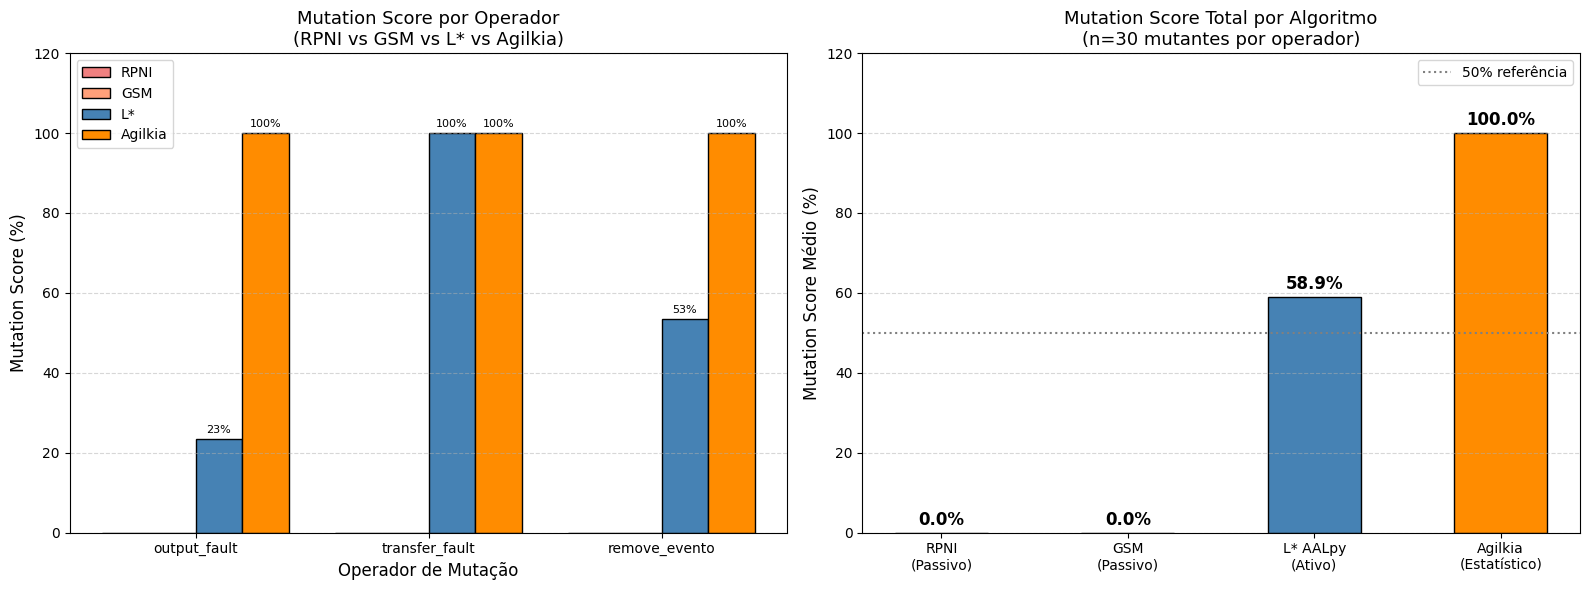

Figura salva: mutation_score_4algoritmos.png


In [17]:
# --- Gráfico comparativo — 4 algoritmos ---

operadores_nomes = ['output_fault', 'transfer_fault', 'remove_evento']
algoritmos = ['RPNI\n(Passivo)', 'GSM\n(Passivo)', 'L* AALpy\n(Ativo)', 'Agilkia\n(Estatístico)']

def extrair_scores(resultados):
    return [score for _, _, _, score in resultados]

scores = {
    'RPNI':    extrair_scores(resultados_rpni),
    'GSM':     extrair_scores(resultados_gsm),
    'L*':      extrair_scores(resultados_aalpy),
    'Agilkia': extrair_scores(resultados_agilkia),
}
totais = {k: sum(v)/len(v) for k, v in scores.items()}
cores  = {'RPNI': 'lightcoral', 'GSM': 'lightsalmon', 'L*': 'steelblue', 'Agilkia': 'darkorange'}
chaves = ['RPNI', 'GSM', 'L*', 'Agilkia']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Figura 1 — por operador
x = np.arange(len(operadores_nomes))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
ax1 = axes[0]
for chave, offset in zip(chaves, offsets):
    bars = ax1.bar(x + offset * width, scores[chave], width,
                   label=chave, color=cores[chave], edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, h + 1,
                     f'{h:.0f}%', ha='center', va='bottom', fontsize=8)
ax1.set_xlabel('Operador de Mutação', fontsize=12)
ax1.set_ylabel('Mutation Score (%)', fontsize=12)
ax1.set_title('Mutation Score por Operador\n(RPNI vs GSM vs L* vs Agilkia)', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(operadores_nomes, fontsize=10)
ax1.set_ylim(0, 120)
ax1.legend(fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Figura 2 — total
ax2 = axes[1]
valores     = [totais[k] for k in chaves]
cores_plot  = [cores[k] for k in chaves]
bars = ax2.bar(algoritmos, valores, color=cores_plot, edgecolor='black', width=0.5)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mutation Score Médio (%)', fontsize=12)
ax2.set_title(f'Mutation Score Total por Algoritmo\n(n={N_MUTANTES} mutantes por operador)', fontsize=13)
ax2.set_ylim(0, 120)
ax2.axhline(y=50, color='gray', linestyle=':', linewidth=1.5, label='50% referência')
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('mutation_score_4algoritmos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: mutation_score_4algoritmos.png')

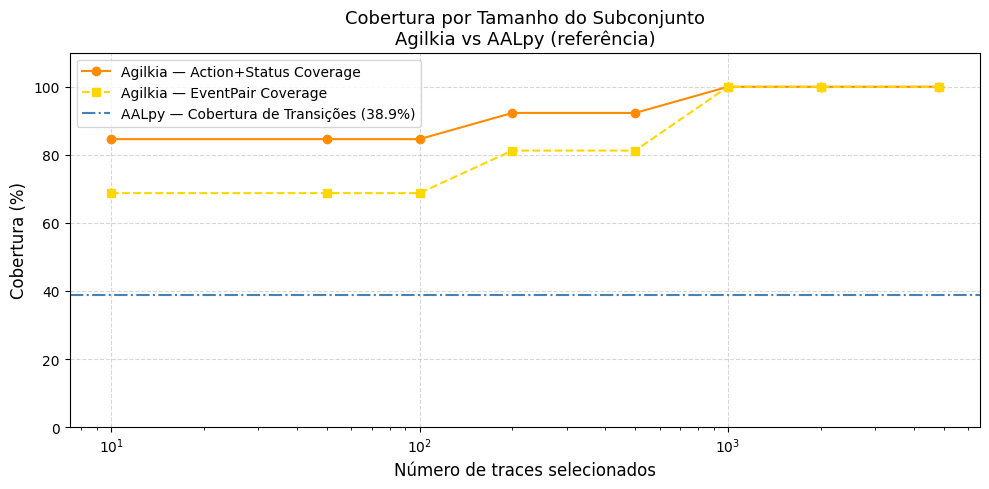

Figura salva: cobertura_comparativa.png


In [18]:
# --- Gráfico de cobertura ---
ns, cobs_asc, cobs_epc = zip(*resultados_cob)

fig2, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(ns, [c*100 for c in cobs_asc], marker='o', label='Agilkia — Action+Status Coverage', color='darkorange')
ax3.plot(ns, [c*100 for c in cobs_epc], marker='s', label='Agilkia — EventPair Coverage', color='gold', linestyle='--')
ax3.axhline(y=cobertura_pct, color='steelblue', linestyle='-.', linewidth=1.5,
            label=f'AALpy — Cobertura de Transições ({cobertura_pct:.1f}%)')
ax3.set_xlabel('Número de traces selecionados', fontsize=12)
ax3.set_ylabel('Cobertura (%)', fontsize=12)
ax3.set_title('Cobertura por Tamanho do Subconjunto\nAgilkia vs AALpy (referência)', fontsize=13)
ax3.set_xscale('log')
ax3.set_ylim(0, 110)
ax3.legend(fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cobertura_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: cobertura_comparativa.png')

In [19]:
# --- Tabela comparativa final ---
r_rpni   = f"{totais['RPNI']:.1f}%"
r_gsm    = f"{totais['GSM']:.1f}%"
r_lstar  = f"{totais['L*']:.1f}%"
r_agil   = f"{totais['Agilkia']:.1f}%"
n_states = str(len(model_trie.states))
cob_str  = f"{cobertura_pct:.1f}%"

print('\n' + '=' * 70)
print(' TABELA COMPARATIVA FINAL — 4 Algoritmos')
print('=' * 70)
print(f'{"Métrica":<35} {"RPNI":<10} {"GSM":<10} {"L*":<12} {"Agilkia"}')
print('-' * 70)
print(f'{"Estados no modelo":<35} {"1":<10} {"1":<10} {n_states:<12} {"N/A"}')
print(f'{"Cobertura de transições":<35} {"N/A":<10} {"N/A":<10} {cob_str:<12} {"84.6% (10 traces)"}')

labels = ['output_fault', 'transfer_fault', 'remove_evento']
for i, label in enumerate(labels):
    r  = f"{scores['RPNI'][i]:.1f}%"
    g  = f"{scores['GSM'][i]:.1f}%"
    ls = f"{scores['L*'][i]:.1f}%"
    ag = f"{scores['Agilkia'][i]:.1f}%"
    print(f'{"Mut. Score — " + label:<35} {r:<10} {g:<10} {ls:<12} {ag}')

print(f'{"Mut. Score TOTAL":<35} {r_rpni:<10} {r_gsm:<10} {r_lstar:<12} {r_agil}')
print(f'{"Modelo formal (MEF)":<35} {"Sim":<10} {"Sim":<10} {"Sim":<12} {"Não"}')
print(f'{"Verificação formal":<35} {"Limitada":<10} {"Limitada":<10} {"Sim":<12} {"Não"}')
print('=' * 70)


 TABELA COMPARATIVA FINAL — 4 Algoritmos
Métrica                             RPNI       GSM        L*           Agilkia
----------------------------------------------------------------------
Estados no modelo                   1          1          4            N/A
Cobertura de transições             N/A        N/A        38.9%        84.6% (10 traces)
Mut. Score — output_fault           0.0%       0.0%       23.3%        100.0%
Mut. Score — transfer_fault         0.0%       0.0%       100.0%       100.0%
Mut. Score — remove_evento          0.0%       0.0%       53.3%        100.0%
Mut. Score TOTAL                    0.0%       0.0%       58.9%        100.0%
Modelo formal (MEF)                 Sim        Sim        Sim          Não
Verificação formal                  Limitada   Limitada   Sim          Não


**AICHERNIG - Mutação da MEF e Geração de Sequências Distinguidoras**

In [20]:
def gerar_mutantes_mef(model):
    """
    Gera todos os mutantes da MEF por:
    - Output Fault: troca a saída de uma transição
    - Transfer Fault: redireciona uma transição para outro estado
    """
    mutantes = []
    estados   = model.states
    alfabeto  = model.get_input_alphabet()

    for estado in estados:
        for simbolo in alfabeto:
            saida_orig  = estado.output_fun[simbolo]
            destino_orig = estado.transitions[simbolo]

            # --- Output Fault ---
            outras_saidas = list(set(['ok', 'erro', 'void', 'valor', 'nao_observado']) - {saida_orig})
            for nova_saida in outras_saidas:
                mutantes.append({
                    'tipo'        : 'output_fault',
                    'estado'      : estado.state_id,
                    'simbolo'     : simbolo,
                    'saida_orig'  : saida_orig,
                    'saida_mut'   : nova_saida,
                    'destino_orig': destino_orig.state_id,
                    'destino_mut' : destino_orig.state_id,  # mesmo destino
                })

            # --- Transfer Fault ---
            outros_destinos = [s for s in estados if s.state_id != destino_orig.state_id]
            for novo_destino in outros_destinos:
                mutantes.append({
                    'tipo'        : 'transfer_fault',
                    'estado'      : estado.state_id,
                    'simbolo'     : simbolo,
                    'saida_orig'  : saida_orig,
                    'saida_mut'   : saida_orig,  # mesma saída
                    'destino_orig': destino_orig.state_id,
                    'destino_mut' : novo_destino.state_id,
                })

    print(f"Total de mutantes gerados: {len(mutantes)}")
    print(f"  Output faults  : {sum(1 for m in mutantes if m['tipo'] == 'output_fault')}")
    print(f"  Transfer faults: {sum(1 for m in mutantes if m['tipo'] == 'transfer_fault')}")
    return mutantes

mutantes_mef = gerar_mutantes_mef(model_trie)

Total de mutantes gerados: 252
  Output faults  : 144
  Transfer faults: 108


*Encontrar a sequência distinguidora para cada mutante*

In [21]:
def encontrar_sequencia_distinguidora(model, mutante, max_profundidade=10):
    """
    Busca BFS uma sequência de entrada que produz saída diferente
    entre o modelo original e o mutante.
    Retorna a sequência distinguidora ou None se não encontrar.
    """
    from collections import deque

    alfabeto    = model.get_input_alphabet()
    estado_map  = {s.state_id: s for s in model.states}

    estado_mut_id   = mutante['estado']
    simbolo_mut     = mutante['simbolo']
    saida_mut       = mutante['saida_mut']
    destino_mut_id  = mutante['destino_mut']

    def step_original(estado_id, simbolo):
        s = estado_map[estado_id]
        return s.output_fun[simbolo], s.transitions[simbolo].state_id

    def step_mutante(estado_id, simbolo):
        # Aplica a mutação apenas na transição afetada
        if estado_id == estado_mut_id and simbolo == simbolo_mut:
            if mutante['tipo'] == 'output_fault':
                return saida_mut, estado_map[estado_id].transitions[simbolo].state_id
            else:  # transfer_fault
                return estado_map[estado_id].output_fun[simbolo], destino_mut_id
        # Demais transições: comportamento original
        s = estado_map[estado_id]
        return s.output_fun[simbolo], s.transitions[simbolo].state_id

    # BFS: (sequencia, estado_orig, estado_mut)
    inicial = ([], model.initial_state.state_id, model.initial_state.state_id)
    fila = deque([inicial])
    visitados = set()

    while fila:
        sequencia, est_orig, est_mut = fila.popleft()

        if len(sequencia) > max_profundidade:
            continue

        chave = (tuple(sequencia), est_orig, est_mut)
        if chave in visitados:
            continue
        visitados.add(chave)

        for simbolo in alfabeto:
            saida_o, prox_orig = step_original(est_orig, simbolo)
            saida_m, prox_mut  = step_mutante(est_mut,  simbolo)

            nova_seq = sequencia + [simbolo]

            if saida_o != saida_m:
                return nova_seq, saida_o, saida_m  # distinguidora encontrada!

            fila.append((nova_seq, prox_orig, prox_mut))

    return None, None, None


# Roda para todos os mutantes
print("Gerando sequências distinguidoras...\n")

distinguidoras = []
sem_distinguidora = []

for i, mutante in enumerate(mutantes_mef):
    seq, saida_o, saida_m = encontrar_sequencia_distinguidora(model_trie, mutante)
    if seq:
        distinguidoras.append({
            'mutante'  : mutante,
            'sequencia': seq,
            'saida_orig': saida_o,
            'saida_mut' : saida_m
        })
    else:
        sem_distinguidora.append(mutante)

print(f"Mutantes com sequência distinguidora : {len(distinguidoras)}/{len(mutantes_mef)}")
print(f"Mutantes sem sequência distinguidora : {len(sem_distinguidora)}/{len(mutantes_mef)}")
print(f"\nExemplos de sequências encontradas:")
for d in distinguidoras[:5]:
    m = d['mutante']
    print(f"  [{m['tipo']}] {m['estado']} --[{m['simbolo'].strip()}]-->")
    print(f"    Sequência : {[s.strip() for s in d['sequencia']]}")
    print(f"    Original  : {d['saida_orig']}")
    print(f"    Mutante   : {d['saida_mut']}")
    print()

Gerando sequências distinguidoras...

Mutantes com sequência distinguidora : 252/252
Mutantes sem sequência distinguidora : 0/252

Exemplos de sequências encontradas:
  [output_fault] s0 --[scanner(produto)]-->
    Sequência : ['scanner(produto)']
    Original  : ok
    Mutante   : valor

  [output_fault] s0 --[scanner(produto)]-->
    Sequência : ['scanner(produto)']
    Original  : ok
    Mutante   : erro

  [output_fault] s0 --[scanner(produto)]-->
    Sequência : ['scanner(produto)']
    Original  : ok
    Mutante   : nao_observado

  [output_fault] s0 --[scanner(produto)]-->
    Sequência : ['scanner(produto)']
    Original  : ok
    Mutante   : void

  [transfer_fault] s0 --[scanner(produto)]-->
    Sequência : ['scanner(produto)', 'debloquer']
    Original  : nao_observado
    Mutante   : ok



*Diferença aparece no estado seguinte, não na transição mutada em si.*
*Usar sequências como contraexemplos no oráculo do L**

In [22]:
# Extrai todas as sequências distinguidoras como contraexemplos
contraexemplos = [d['sequencia'] for d in distinguidoras]

# Remove duplicatas mantendo a ordem
vistos = set()
contraexemplos_unicos = []
for seq in contraexemplos:
    chave = tuple(seq)
    if chave not in vistos:
        vistos.add(chave)
        contraexemplos_unicos.append(seq)

print(f"Total de sequências distinguidoras : {len(contraexemplos)}")
print(f"Sequências únicas                  : {len(contraexemplos_unicos)}")
print(f"Tamanhos: min={min(len(s) for s in contraexemplos_unicos)} "
      f"max={max(len(s) for s in contraexemplos_unicos)} "
      f"média={sum(len(s) for s in contraexemplos_unicos)/len(contraexemplos_unicos):.1f}")

Total de sequências distinguidoras : 252
Sequências únicas                  : 75
Tamanhos: min=1 max=3 média=2.3


In [25]:
class AichernigOracle:
    def __init__(self, alphabet, sul, contraexemplos, num_random=500):
        self.alphabet        = alphabet
        self.sul             = sul
        self.contraexemplos  = contraexemplos
        self.num_random      = num_random
        self.num_queries     = 0  # ← obrigatório pelo AALpy
        self.num_steps       = 0  # ← obrigatório pelo AALpy
        self.random_oracle   = RandomWpMethodEqOracle(
            alphabet, sul, min_length=2, expected_length=10, num_tests=num_random
        )

    def find_cex(self, hypothesis):
        # --- Fase 1: sequências de Aichernig ---
        for seq in self.contraexemplos:
            self.sul.pre()
            self.num_queries += 1
            self.num_steps   += len(seq)
            saidas_hyp = []
            saidas_sul = []

            for simbolo in seq:
                saida_hyp = hypothesis.step(simbolo)
                saida_sul = self.sul.step(simbolo)
                saidas_hyp.append(saida_hyp)
                saidas_sul.append(saida_sul)

            hypothesis.reset_to_initial()
            self.sul.post()

            if saidas_hyp != saidas_sul:
                print(f"  [Aichernig] Contraexemplo: {[s.strip() for s in seq]}")
                print(f"    Hipótese : {saidas_hyp}")
                print(f"    SUL      : {saidas_sul}")
                return seq

        # --- Fase 2: fallback aleatório ---
        cex = self.random_oracle.find_cex(hypothesis)
        self.num_queries += self.random_oracle.num_queries
        self.num_steps   += self.random_oracle.num_steps
        return cex


# Roda novamente
sul_aichernig    = LogSUL(traces_com_status)
oracle_aichernig = AichernigOracle(
    alphabet_real, sul_aichernig, contraexemplos_unicos
)

model_aichernig = run_Lstar(
    alphabet_real, sul_aichernig, oracle_aichernig,
    automaton_type='mealy'
)

print(f"\nModelo aprendido com {len(model_aichernig.states)} estados.")
print(f"Queries Aichernig : {oracle_aichernig.num_queries}")

Hypothesis 1: 4 states.
-----------------------------------
Learning Finished.
Learning Rounds:  1
Number of states: 4
Time (in seconds)
  Total                : 0.01
  Learning algorithm   : 0.0
  Conformance checking : 0.01
Learning Algorithm
 # Membership Queries  : 324
 # MQ Saved by Caching : 9
 # Steps               : 891
Equivalence Query
 # Membership Queries  : 575
 # Steps               : 6642
-----------------------------------

Modelo aprendido com 4 estados.
Queries Aichernig : 575


In [26]:
# Verifica quantas queries vieram de Aichernig vs fallback
print(f"Sequências Aichernig testadas : {len(contraexemplos_unicos)}")
print(f"Total queries equivalência    : {oracle_aichernig.num_queries}")
print(f"Queries fallback aleatório    : {oracle_aichernig.random_oracle.num_queries}")

Sequências Aichernig testadas : 75
Total queries equivalência    : 575
Queries fallback aleatório    : 500
